In [1]:
import os

import pyearthtools.data as petdata
import pyearthtools.pipeline as petpipe
import site_archive_nci

from pyearthtools.data.time import Petdt
from pyearthtools.pipeline.operations.xarray.join import GeospatialTimeSeriesMerge

import xarray as xr

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt


# Set random seed for reproducibility
torch.manual_seed(42)

# Autodetect GPU and use if possible
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [2]:
#helper functions
import numpy as np
def find_closest_index(arr, number):
    """
    Find the index of the closest number in a sorted 1D numpy array.

    Parameters:
    arr (numpy.ndarray): A sorted 1D numpy array.
    number (float): The number to find the closest to.
    
    Returns:
    int: The index of the closest number in the array.
    """
    # Calculate the minimum and maximum of the array
    minval = np.min(arr)
    maxval = np.max(arr)
    
    # Check if the number is within the range of the array
    if number < minval or number > maxval:
        raise ValueError(f"ERROR: The value {number} is out of range. It should be between {minval} and {maxval}.")
    
    # Calculate the absolute differences between the number and elements in the array
    differences = np.abs(arr - number)
    
    # Find the index of the smallest difference
    closest_index = np.argmin(differences)
    
    return closest_index


def get_latlon(ind_lat, ind_lon, xr_dir):
    # get lat lon from examplar grid data 
    ds = xr.open_dataset(xr_dir)
    lat = ds['lat'].to_numpy()[int(ind_lat - 64 / 2): int(ind_lat + 64 / 2)]
    lon = ds['lon'].to_numpy()[int(ind_lon - 64 / 2): int(ind_lon + 64 / 2)]
    return lat, lon

def get_gridded_data(input_dir, output_dir, h, comp, ind_lat, ind_lon):
    # input_dir: in the format of /.../20220101/ 
    # 443, 531 are the center of the grid (Sydney Aiport)
    
    res=64
    #save dat as separate .nc files:
    file = os.path.join(input_dir, h, 'an', 'sfc', f'{comp}.nc')
    ds=xr.open_dataset(file)
    if not os.path.exists(file):
        print(f"File {file} does not exist.")
    dat = ds[comp]
    dat_hour = dat[:, int(443-res/2): int(443+res/2), int(531-res/2): int(531+res/2)]
        
    # get timestamp from input_dir
    date_str = os.path.basename(input_dir) # format 'YYYYMMDD'

    # create a new dataset with the filtered data
    file = os.path.join(output_dir, f'{date_str}.pt')
        
    # convert xarray to 3d tensor in the shape of (1, res, res)
    if isinstance(dat_hour, xr.DataArray):
        dat_hour = dat_hour.values
    dat_hour = torch.from_numpy(dat_hour)

In [3]:
himawari = petdata.archive.Himawari('surface_global_irradiance')

satpipe = petpipe.Pipeline(
    himawari
)

prepare = petpipe.Pipeline(
    satpipe,
    # GeospatialTimeSeriesMerge(reference_dataset=satpipe['2021-06-09T02']), # These are pretty similar grids, so just pick one
    iterator=petpipe.iterators.DateRange(2021, 2023, interval='10 minutes')
)
ipipe = iter(prepare)

merged_sample = next(ipipe)

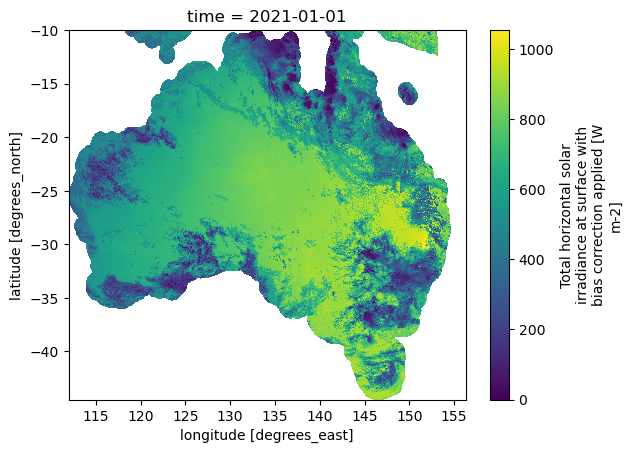

In [4]:
merged_sample['surface_global_irradiance'].isel(time=0).plot()

In [5]:
syd_lat, syd_lon=-33.9465, 151.1731
lat_arr = merged_sample['latitude'].to_numpy()
lon_arr = merged_sample['longitude'].to_numpy()

In [6]:
 # Sydney Airport index: 528, 1959
ind_lat, ind_lon = find_closest_index(lat_arr, syd_lat), find_closest_index(lon_arr, syd_lon)
ind_lat, ind_lon

(np.int64(528), np.int64(1959))

In [7]:
res=64 # crop a 64x64 area centred on Syd airport
dat_crop = merged_sample['surface_global_irradiance'].isel(
    latitude=slice(int(ind_lat-res/2), int(ind_lat+res/2)),
    longitude=slice(int(ind_lon-res/2), int(ind_lon+res/2))
)

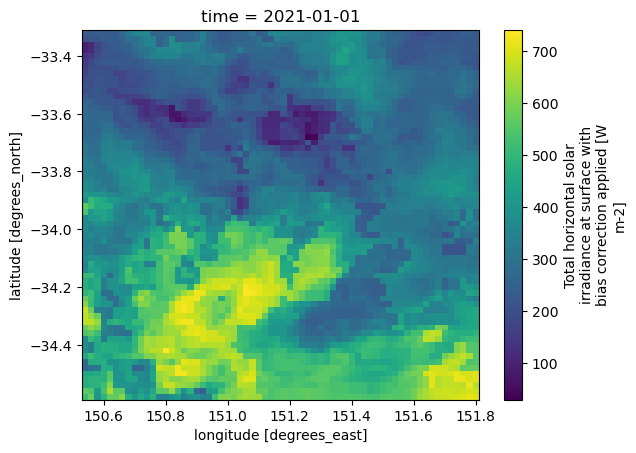

In [8]:
dat_crop.plot()

In [9]:
 merged_sample['surface_global_irradiance'][0,:,:].shape

(1726, 2214)

In [10]:
t=np.datetime_as_string(merged_sample['time'].values[0])

In [11]:
dt = t.astype('datetime64[ms]').astype(object)

In [12]:
formatted = dt.strftime('%Y%m%d%H%M')
formatted

'202101010000'

In [13]:
prepare = petpipe.Pipeline(
    satpipe,
    # GeospatialTimeSeriesMerge(reference_dataset=satpipe['2021-06-09T02']), # These are pretty similar grids, so just pick one
    iterator=petpipe.iterators.DateRange(2021, 2023, interval='10 minutes')
)
ipipe = iter(prepare)

In [14]:
output_dir = '/scratch/nf33/cd3022/pyearth'
for i in range(0, 10):
    merged_sample = next(ipipe)
    #get time label
    t=np.datetime_as_string(merged_sample['time'].values[0])
    dt = t.astype('datetime64[ms]').astype(object)
    formatted = dt.strftime('%Y%m%d%H%M')
    dat_crop = merged_sample['surface_global_irradiance'].isel(
        time=0,
        latitude=slice(int(ind_lat-res/2), int(ind_lat+res/2)),
        longitude=slice(int(ind_lon-res/2), int(ind_lon+res/2))
    )

    file = os.path.join(output_dir, f'{formatted}.pt')
    if isinstance(dat_crop, xr.DataArray):
        dat_crop = dat_crop.values
    dat_crop = torch.from_numpy(dat_crop)
    torch.save(dat_crop, file)

In [15]:
dat_crop.shape

torch.Size([64, 64])